# Deliverable 1: Data Collection, Cleaning, and Exploration

## Advanced Data Mining Project

Dataset: `ecommerce_user_dataset_cleaned.csv`

This notebook covers:

- Dataset selection and justification
- Data loading and structure inspection
- Data cleaning and quality checks
- Exploratory Data Analysis (EDA)
- Insights that guide future modeling


## 1. Dataset Selection and Justification

The dataset is an e-commerce customer behavior dataset with **1,000 records** and **8 attributes**, satisfying the project requirement of at least 500 records and 8-10 attributes.

### Why this dataset is appropriate

- It contains behavioral and transactional signals useful for data mining.
- It includes a segment label (`Customer_Segment`), enabling supervised learning later.
- It also supports unsupervised tasks like clustering based on customer behavior patterns.


In [4]:
# Core libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Seaborn is optional; notebook falls back to matplotlib-only visuals if unavailable
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

print('Seaborn available:', HAS_SEABORN)

Seaborn available: True


In [5]:
# 2. Load the dataset and inspect structure
file_path = 'ecommerce_user_dataset_cleaned.csv'
df = pd.read_csv(file_path)

print('Shape (rows, columns):', df.shape)
print('\nColumns:')
print(df.columns.tolist())

print('\nData types:')
print(df.dtypes)

df.head()

Shape (rows, columns): (1000, 8)

Columns:
['Customer_ID', 'Purchase_History', 'Transaction_Frequency', 'Monetary_Value', 'Browsing_Behavior', 'Engagement_Score', 'Time_on_Site', 'Customer_Segment']

Data types:
Customer_ID                  str
Purchase_History           int64
Transaction_Frequency    float64
Monetary_Value           float64
Browsing_Behavior        float64
Engagement_Score         float64
Time_on_Site             float64
Customer_Segment             str
dtype: object


,Customer_ID,Purchase_History,Transaction_Frequency,Monetary_Value,Browsing_Behavior,Engagement_Score,Time_on_Site,Customer_Segment
0,CUST0001,23,0.258,664.090,88.100,0.260,11.840,Iron
1,CUST0002,15,0.378,"4,244.210",5.870,0.280,35.040,Copp
2,CUST0003,21,2.578,"4,638.470",23.880,0.930,10.140,Copp
3,CUST0004,25,1.750,"7,277.560",89.840,0.020,22.020,Iron
4,CUST0005,15,1.322,"5,785.450",26.360,0.700,42.120,Copp


In [6]:
# 3. Baseline data quality checks before cleaning
missing_counts = df.isna().sum()
duplicate_count = df.duplicated().sum()

print('Missing values per column:')
print(missing_counts)
print('\nDuplicate rows:', duplicate_count)

# Check for basic inconsistent ranges in known bounded features
invalid_engagement = ((df['Engagement_Score'] < 0) |
                      (df['Engagement_Score'] > 1)).sum()
invalid_time = (df['Time_on_Site'] < 0).sum()

print('\nInvalid Engagement_Score values (<0 or >1):', invalid_engagement)
print('Invalid Time_on_Site values (<0):', invalid_time)

Missing values per column:
Customer_ID              0
Purchase_History         0
Transaction_Frequency    0
Monetary_Value           0
Browsing_Behavior        0
Engagement_Score         0
Time_on_Site             0
Customer_Segment         0
dtype: int64

Duplicate rows: 0

Invalid Engagement_Score values (<0 or >1): 0
Invalid Time_on_Site values (<0): 0


In [7]:
# 4. Data cleaning
# Even though this dataset is already mostly clean, we still apply reproducible checks and safeguards.
df_clean = df.copy()

cleaning_log = {}

# Standardize column names for consistency
df_clean.columns = [c.strip() for c in df_clean.columns]

# Remove duplicates (if any)
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
cleaning_log['duplicates_removed'] = before - len(df_clean)

# Handle missing values generically to keep the cleaning pipeline reusable
num_cols = ['Purchase_History', 'Transaction_Frequency', 'Monetary_Value',
            'Browsing_Behavior', 'Engagement_Score', 'Time_on_Site']
cat_cols = ['Customer_ID', 'Customer_Segment']

numeric_missing_before = df_clean[num_cols].isna().sum().sum()
categorical_missing_before = df_clean[cat_cols].isna().sum().sum()

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

cleaning_log['numeric_missing_imputed'] = int(numeric_missing_before)
cleaning_log['categorical_missing_imputed'] = int(categorical_missing_before)

# Enforce numeric type consistency
for col in num_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# If coercion introduced NaN, fill again with medians
for col in num_cols:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Address potential noisy data using IQR capping (winsorization)
# This keeps extreme values from dominating later models while preserving most records.
outlier_counts = {}
for col in num_cols:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_counts[col] = int(outliers)

    # Keep original values in a backup column only when outliers exist
    if outliers > 0:
        df_clean[f'{col}_Original'] = df_clean[col]
        df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

cleaning_log['iqr_outliers_detected'] = outlier_counts

print('Cleaning summary:')
for k, v in cleaning_log.items():
    print(f'- {k}: {v}')

print('\nFinal shape after cleaning:', df_clean.shape)

Cleaning summary:
- duplicates_removed: 0
- numeric_missing_imputed: 0
- categorical_missing_imputed: 0
- iqr_outliers_detected: {'Purchase_History': 0, 'Transaction_Frequency': 54, 'Monetary_Value': 0, 'Browsing_Behavior': 0, 'Engagement_Score': 0, 'Time_on_Site': 0}

Final shape after cleaning: (1000, 9)


## 5. Exploratory Data Analysis (EDA)

The following visualizations examine distributions, outliers, relationships, and customer segment behavior.


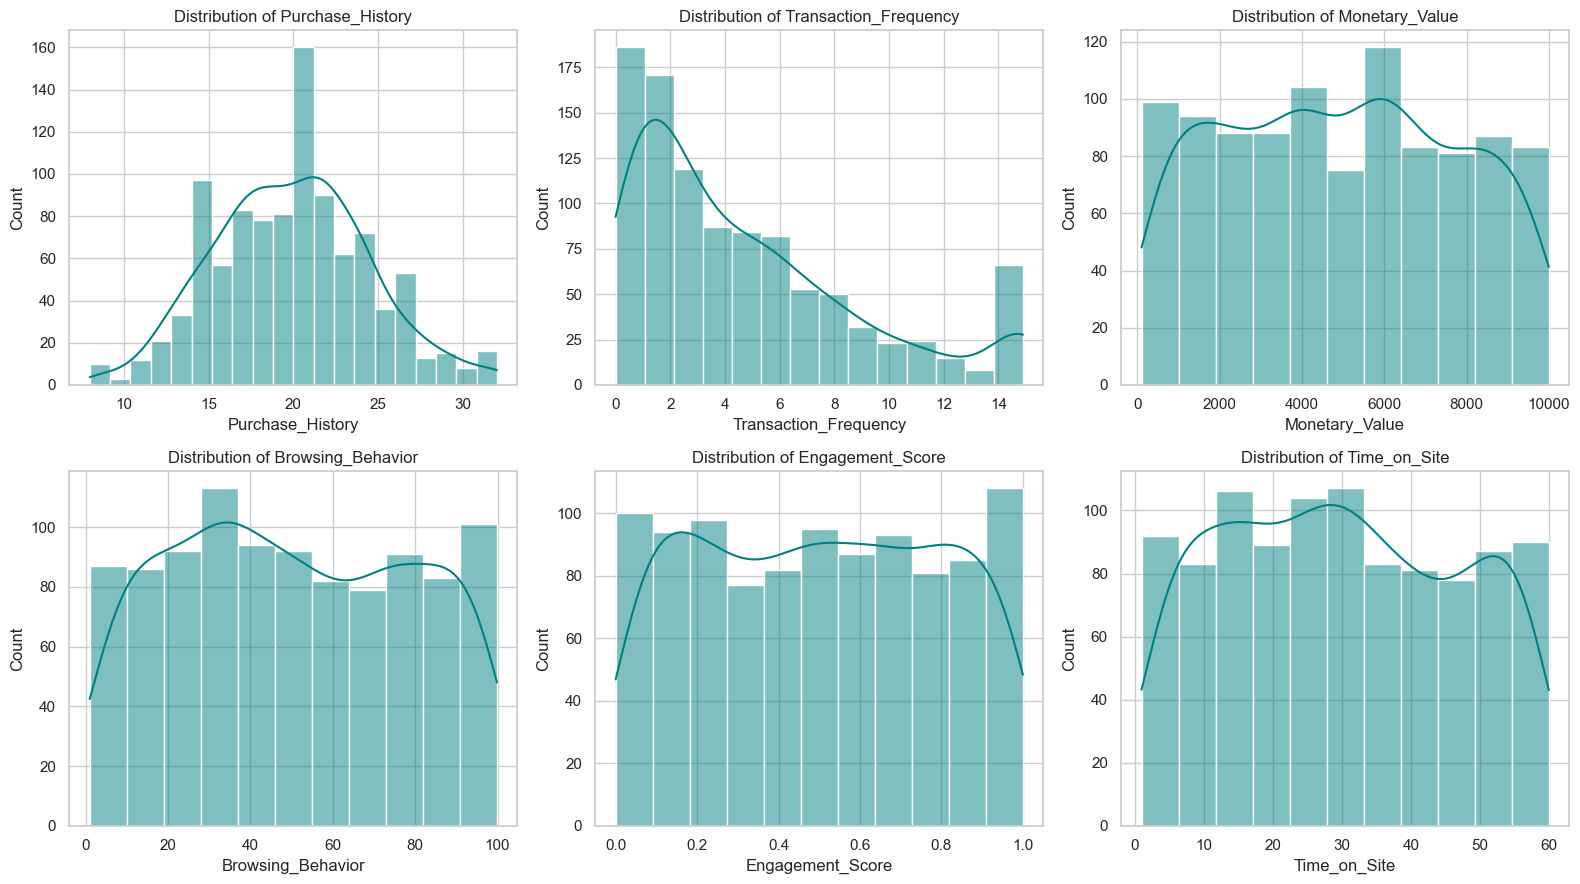

In [8]:
# Univariate distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    if HAS_SEABORN:
        sns.histplot(df_clean[col], kde=True, ax=axes[i], color='teal')
    else:
        axes[i].hist(df_clean[col], bins=30, color='teal', alpha=0.8)
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

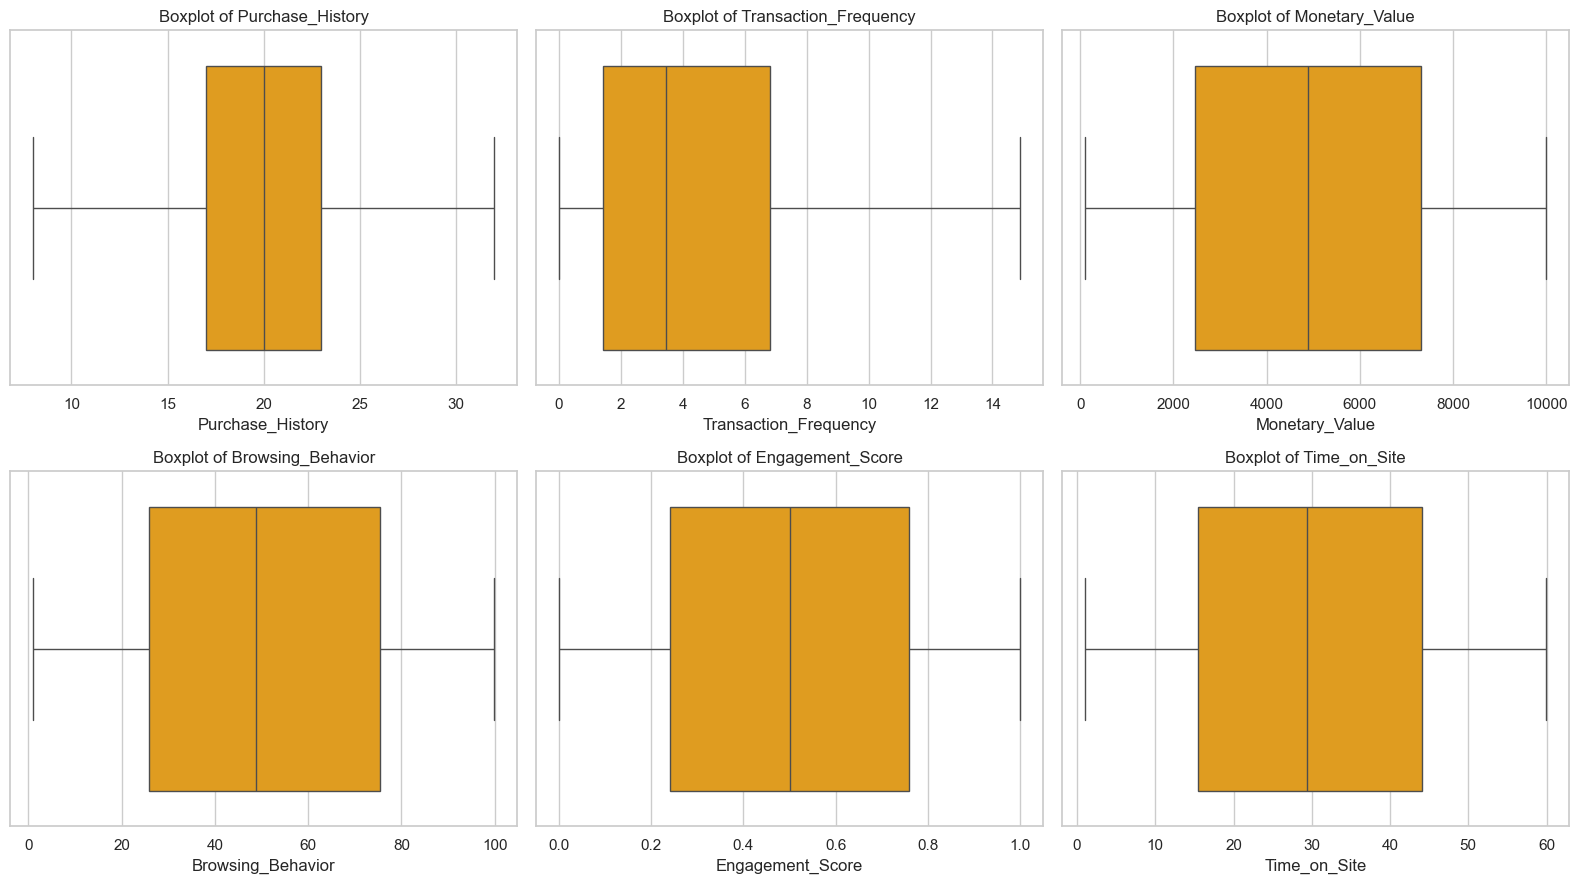

In [9]:
# Boxplots for outlier inspection
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    if HAS_SEABORN:
        sns.boxplot(x=df_clean[col], ax=axes[i], color='orange')
    else:
        axes[i].boxplot(df_clean[col], vert=False)
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

Customer Segment distribution (%):
Customer_Segment
Copp   71.800
Iron   28.200
Name: count, dtype: float64


/var/folders/v5/2dnyj4hn4q13nbgkpmzk9cvr0000gn/T/ipykernel_82758/735559752.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Customer_Segment', palette='Set2')


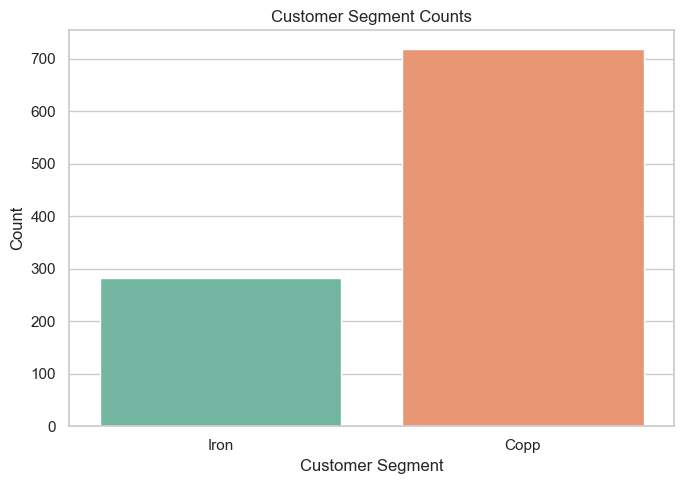

In [10]:
# Categorical distribution of target-like feature
segment_counts = df_clean['Customer_Segment'].value_counts()
segment_pct = (segment_counts / len(df_clean) * 100).round(2)

print('Customer Segment distribution (%):')
print(segment_pct)

plt.figure(figsize=(7, 5))
if HAS_SEABORN:
    sns.countplot(data=df_clean, x='Customer_Segment', palette='Set2')
else:
    segment_counts.plot(kind='bar', color=['#66c2a5', '#fc8d62'])

plt.title('Customer Segment Counts')
plt.xlabel('Customer Segment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

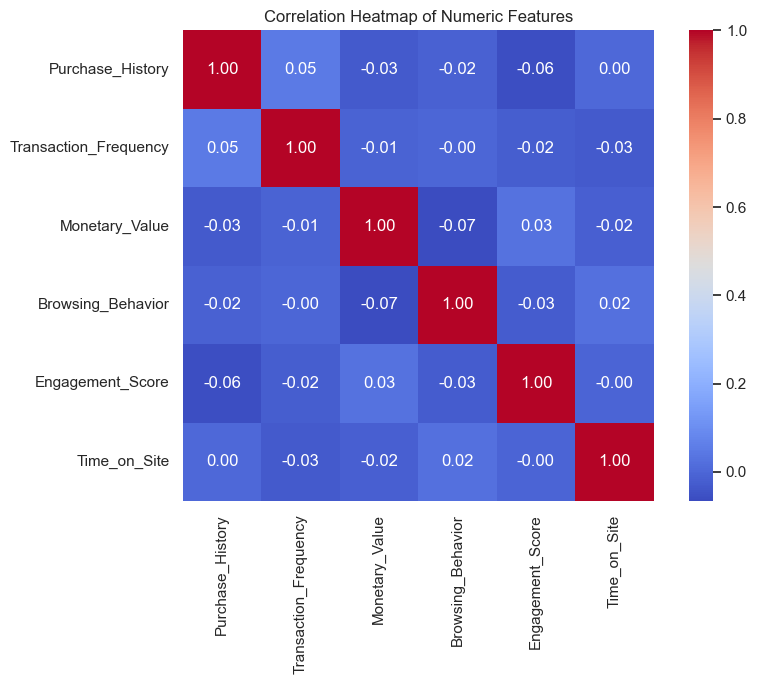

,Purchase_History,Transaction_Frequency,Monetary_Value,Browsing_Behavior,Engagement_Score,Time_on_Site
Purchase_History,1.000,0.050,-0.030,-0.015,-0.058,0.001
Transaction_Frequency,0.050,1.000,-0.008,-0.002,-0.022,-0.030
Monetary_Value,-0.030,-0.008,1.000,-0.066,0.027,-0.018
Browsing_Behavior,-0.015,-0.002,-0.066,1.000,-0.026,0.023
Engagement_Score,-0.058,-0.022,0.027,-0.026,1.000,-0.004
Time_on_Site,0.001,-0.030,-0.018,0.023,-0.004,1.000


In [11]:
# Correlation analysis to inspect linear relationships among numeric features
corr = df_clean[num_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
if HAS_SEABORN:
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
else:
    plt.imshow(corr, cmap='coolwarm', aspect='auto')
    plt.colorbar()
    plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha='right')
    plt.yticks(range(len(num_cols)), num_cols)

plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

corr

,Purchase_History,Transaction_Frequency,Monetary_Value,Browsing_Behavior,Engagement_Score,Time_on_Site
Customer_Segment,,,,,,
Copp,19.750,4.650,"5,706.760",49.440,0.580,29.990
Iron,20.210,4.770,"2,938.870",52.210,0.300,29.480


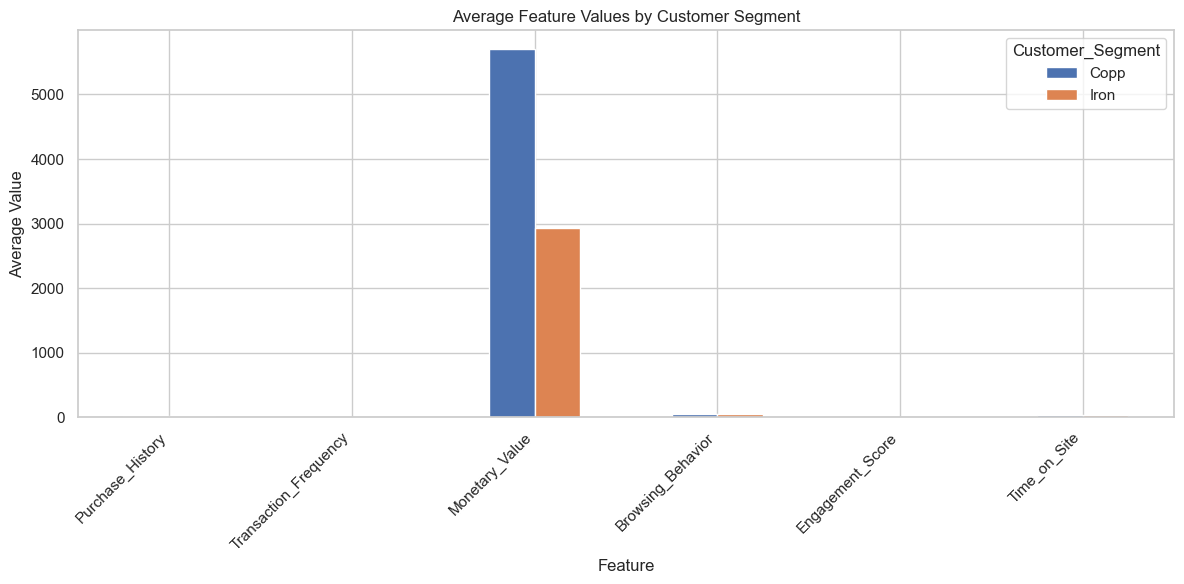

In [12]:
# Compare segment means to identify behavioral differences
segment_means = df_clean.groupby('Customer_Segment')[num_cols].mean().round(2)
display(segment_means)

segment_means.T.plot(kind='bar', figsize=(12, 6))
plt.title('Average Feature Values by Customer Segment')
plt.xlabel('Feature')
plt.ylabel('Average Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Key Insights from EDA

1. **Data quality is high**: no missing values, no duplicate rows, and no invalid bounded values detected.
2. **Class imbalance exists**: `Customer_Segment` is skewed toward `Copp` (~71.8%) vs `Iron` (~28.2%).
3. **Weak linear correlations** among numeric predictors suggest non-linear models or interaction features may perform better.
4. **Outlier behavior is limited**: only `Transaction_Frequency` showed IQR outliers, which were capped for robustness.
5. **Segment-level means are relatively close**, indicating that richer feature engineering may be needed to improve segment discrimination.


## 7. How These Insights Guide Future Modeling

- For **classification**, address imbalance with class weights or resampling and prioritize metrics like F1-score/ROC-AUC over accuracy alone.
- For **regression**, select a suitable continuous target (for example `Monetary_Value`) and test regularized + tree-based models.
- For **clustering**, standardize numeric features and evaluate cluster quality with silhouette score.
- For **association rules**, discretize numeric behavior features into bins to build transaction-like patterns.

The cleaned working DataFrame for the next deliverable is `df_clean`.
